# Notebook Purpose: Testing the use of TP-classification threshold=8ms after filtering out human annotations < 3dB SNR and then looking at what kind of overlaps are considered as true positives or false positives and how many

## Imports Section:

In [1]:
import numpy as np
import pandas as pd
import random
import scipy
from scipy import stats
import datetime as dt
import dask.dataframe as dd

In [2]:
import glob
import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches
from pathlib import Path

In [3]:
import convert_between_detector_file_formats as conversion

## Function and Constant Definitions

In [4]:
FREQ_COLORS = {'LF':'cyan', 'HF':'orange'}
FILE_SITES = {'20220730_053000':'Carp',
 '20220826_070000':'Central',
 '20220727_083000':'Foliage',
 '20220829_090000':'Foliage'}

RAVENPRO_TABLE_EXTENSION = ".txt"
RAVENPRO_TABLE_FORMAT = "\t"
RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR = f'{Path.home()}/Documents/Research/mila_files/mila-human-wav-txt'
BD2_DETS_SAVE_DIR = Path(f'20250127__group_threshold_sweep_results')
TP_CLASSIFICATION_THRESHOLD = 0.008
OVERLAP_TIME_THRESHOLD = 0.012
SITE_NAMES = {'Carp':'Carp Pond', 'Foliage':'Foliage', 'Central':'Central Pond'}

### Below are the functions used for converting between detector formats

In [5]:
def return_true_positives_using_human_df(human_df, machine_df):
    dist_matrix = np.zeros((len(machine_df), len(human_df)))
    association_matrix = np.zeros((len(machine_df), len(human_df)), dtype='bool')
    collect_human = pd.DataFrame()
    collect_bd2 = pd.DataFrame()
    for index in range(len(machine_df)):
        batdetect2_row = machine_df.iloc[index]
        dist_to_all_calls = ((human_df['peak_frequency_time'] - batdetect2_row['peak_frequency_time_SPECTROGRAM']).values)
        dist_matrix[index,:] = dist_to_all_calls
    
        dist_to_all_calls[np.abs(dist_to_all_calls)>=TP_CLASSIFICATION_THRESHOLD] = 1
        dist_to_all_calls[np.abs(dist_to_all_calls)<TP_CLASSIFICATION_THRESHOLD] = 0
        if np.abs(dist_to_all_calls-1).sum() > 1:
            collect_human = pd.concat([collect_human, human_df[dist_to_all_calls<0.5]])
            collect_bd2 = pd.concat([collect_bd2, pd.DataFrame(batdetect2_row).T])

        association_matrix[index,:] = ~dist_to_all_calls.astype('bool')

    human_bd2_true_positives = human_df.loc[np.logical_or.reduce(association_matrix, axis=0)]
    machine_false_negatives = human_df.loc[~(np.logical_or.reduce(association_matrix, axis=0))]
    machine_true_positives = machine_df.loc[np.logical_or.reduce(association_matrix, axis=1)]
    machine_false_positives = machine_df.loc[~(np.logical_or.reduce(association_matrix, axis=1))]

    separated_performance_dfs = dict()
    separated_performance_dfs['machine_true_positives'] = machine_true_positives
    separated_performance_dfs['machine_false_positives'] = machine_false_positives
    separated_performance_dfs['machine_false_negatives'] = machine_false_negatives
    separated_performance_dfs['human_true_positives'] = human_bd2_true_positives

    return association_matrix, separated_performance_dfs

![image](example_confusion_matrix.png)

In [6]:
file_keys = list(FILE_SITES.keys())
file_keys

['20220730_053000', '20220826_070000', '20220727_083000', '20220829_090000']

In [7]:
wav_filename = '20220826_070000'
site = FILE_SITES[wav_filename]
plot_file = Path(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{wav_filename}.WAV')
raventxt_human_filename = f'{wav_filename}_manually_verified_by_AK_with_groups'

In [8]:
snr_included_ravenpro_human_txt = pd.read_csv(f'{RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR}/{raventxt_human_filename}_ravenpro_SNR_aditya_SNR_and_peakfreqtime.txt', sep=RAVENPRO_TABLE_FORMAT)
bd2_human_df_file = snr_included_ravenpro_human_txt.copy()
bd2_human_df_file = bd2_human_df_file.drop(columns=['Selection', 'View', 'Channel'])
bd2_human_df_file.rename(columns={'Begin Time (s)':'start_time',
                            'End Time (s)':'end_time',
                            'Low Freq (Hz)':'low_freq',
                            'High Freq (Hz)':'high_freq',
                            'Delta Time (s)':'delta_time_s',
                            'Manually-Verified Phonic Group':'freq_group',
                            'SNR NIST Quick (dB)':'snr_nist_quick_dB'}, inplace=True)
bd2_human_df_file.sort_values('start_time', inplace=True)
bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['adityas_method_snr_dB']>=3].copy()
lf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='LF'].reset_index(drop=True).copy()
hf_bd2_human_df_file = bd2_human_df_file[bd2_human_df_file['freq_group']=='HF'].reset_index(drop=True).copy()
len(bd2_human_df_file), len(lf_bd2_human_df_file), len(hf_bd2_human_df_file)

(3137, 715, 2422)

In [9]:
args = dict()
args['chunk_size'] = 2
args['detection_threshold'] = 0.00
ones = int(args['detection_threshold'])
decimals = int(int(100*(args['detection_threshold'])) % 100)
threshold_tag = f"threshold{ones}p{decimals:02}"
save_loc_reduced_overlaps = Path(f"bd2__{threshold_tag}_chunksize{int(args['chunk_size'])}_{wav_filename}_REDUCED_OVERLAPS.csv")
filepath_reduced_overlaps = BD2_DETS_SAVE_DIR / save_loc_reduced_overlaps
bd2_file_all_dets = pd.read_csv(filepath_reduced_overlaps, sep=',', index_col=0)
bd2_file_all_dets.rename(columns={'KMEANS_CLASSES':'freq_group'}, inplace=True)
lf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='LF'].reset_index(drop=True).copy()
hf_bd2_file_all_dets = bd2_file_all_dets[bd2_file_all_dets['freq_group']=='HF'].reset_index(drop=True).copy()

In [10]:
lf_association_matrix, lf_separated_performance_dfs = return_true_positives_using_human_df(lf_bd2_human_df_file, lf_bd2_file_all_dets)
hf_association_matrix, hf_separated_performance_dfs = return_true_positives_using_human_df(hf_bd2_human_df_file, hf_bd2_file_all_dets)

In [11]:
np.logical_or.reduce(lf_association_matrix, axis=1).shape, np.logical_or.reduce(hf_association_matrix, axis=1).shape, 

((29783,), (22936,))

In [12]:
lf_association_matrix[np.logical_or.reduce(lf_association_matrix, axis=1),:].shape, hf_association_matrix[np.logical_or.reduce(hf_association_matrix, axis=1),:].shape

((673, 715), (2397, 2422))

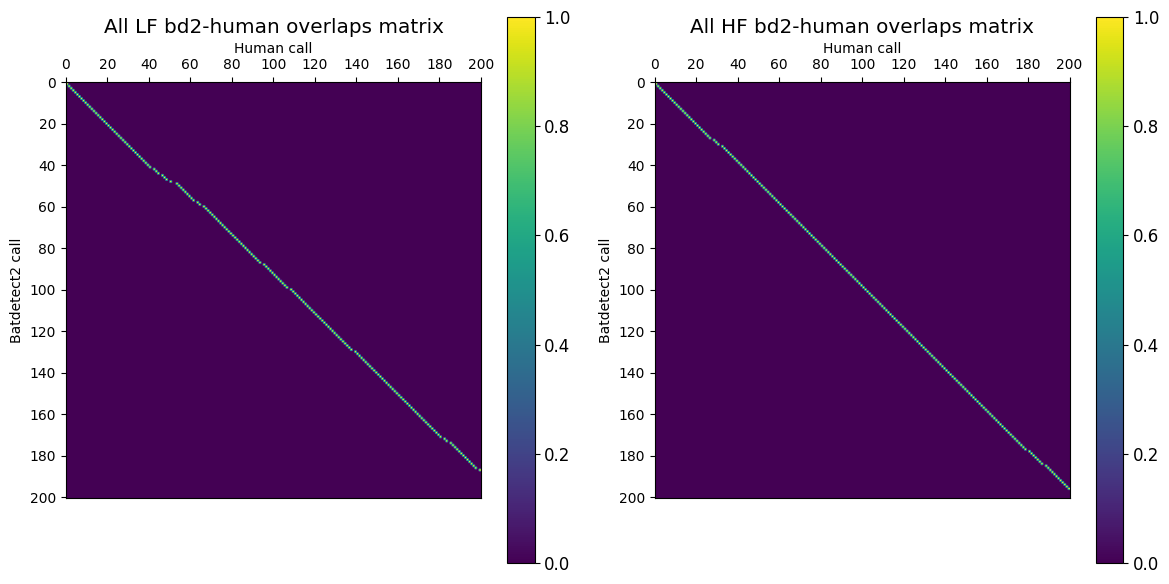

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,6))
plt.rcParams.update({'font.size':12})

samples=200
ax1.set_title('All LF bd2-human overlaps matrix')
im = ax1.imshow((lf_association_matrix[np.logical_or.reduce(lf_association_matrix, axis=1),:])[:samples,:samples])
ax1.set_xlabel('Human call')
ax1.xaxis.set_label_position('top')
ax1.set_ylabel('Batdetect2 call')
ax1.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
fig.colorbar(im, orientation='vertical')
ax1.set_xticks(np.linspace(0, samples, 11)-0.75,
              np.linspace(0, samples, 11).astype(int))
ax1.set_yticks(np.linspace(0, samples, 11)-0.925,
              np.linspace(0, samples, 11).astype(int))



samples=200
ax2.set_title('All HF bd2-human overlaps matrix')
im = ax2.imshow((hf_association_matrix[np.logical_or.reduce(hf_association_matrix, axis=1),:])[:samples,:samples])
ax2.set_xlabel('Human call')
ax2.xaxis.set_label_position('top')
ax2.set_ylabel('Batdetect2 call')
ax2.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
fig.colorbar(im, orientation='vertical')
ax2.set_xticks(np.linspace(0, samples, 11)-0.75,
              np.linspace(0, samples, 11).astype(int))
ax2.set_yticks(np.linspace(0, samples, 11)-0.925,
              np.linspace(0, samples, 11).astype(int))

plt.tight_layout()
plt.show()

In [14]:
hf_human_true_positives = lf_separated_performance_dfs['human_true_positives']
lf_bd2_false_negatives = lf_separated_performance_dfs['machine_false_negatives']
lf_bd2_true_positives = lf_separated_performance_dfs['machine_true_positives']
lf_bd2_false_positives = lf_separated_performance_dfs['machine_false_positives']
print(len(hf_human_true_positives), len(lf_bd2_false_negatives), len(lf_bd2_true_positives), len(lf_bd2_false_positives))

673 42 673 29110


In [15]:
hf_human_true_positives = hf_separated_performance_dfs['human_true_positives']
hf_bd2_false_negatives = hf_separated_performance_dfs['machine_false_negatives']
hf_bd2_true_positives = hf_separated_performance_dfs['machine_true_positives']
hf_bd2_false_positives = hf_separated_performance_dfs['machine_false_positives']
print(len(hf_human_true_positives), len(hf_bd2_false_negatives), len(hf_bd2_true_positives), len(hf_bd2_false_positives))

2398 24 2397 20539


In [16]:
num_trues_each_row = lf_association_matrix.sum(axis=1)
bd2_dets_with_overlap_human_dets = lf_bd2_file_all_dets.iloc[np.where(num_trues_each_row>1)[0]]
print(bd2_dets_with_overlap_human_dets.index.values)
lf_bd2_human_df_file[lf_association_matrix[3209,:]]

[]


,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time


In [18]:
num_trues_each_col = lf_association_matrix.sum(axis=0)
human_dets_with_overlap_bd2_dets = lf_bd2_human_df_file.iloc[np.where(num_trues_each_col>1)[0]]
print(human_dets_with_overlap_bd2_dets.index.values)
lf_bd2_file_all_dets[lf_association_matrix[:,561]]

[]


,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
14229,LF,805.1228,24000.0,24960.0,13.768602,805.1095,805.1352,23750,27581,Nyctalus leisleri,0.332,0.414,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [19]:
plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 24})
for i, sel_ind in enumerate((human_dets_with_overlap_bd2_dets.index).values):
    plt.subplot(2,4,i+1)
    selection_row = lf_bd2_human_df_file.iloc[sel_ind]
    file_name = f'{wav_filename}.WAV'
    file_path = Path(RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.06
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time']-start, linestyle='dashed', color='yellow')

    plot_bd2dets = lf_bd2_file_all_dets[(lf_bd2_file_all_dets['start_time']>=start)&(lf_bd2_file_all_dets['end_time']<=(start+duration))]
    for i, row in plot_bd2dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='cyan', 
                label=f"Δt = {round(1000*(row['peak_frequency_time_SPECTROGRAM'] - selection_row['peak_frequency_time']), 3)}ms")

    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.legend(fontsize=18)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

<Figure size 2000x1000 with 0 Axes>

Above the detections within the `TP_CLASSIFICATION_THRESHOLD` are part of the true positives. They are within `TP_CLASSIFICATION_THRESHOLD` of the human annotation but NOT within `OVERLAP_TIME_THRESHOLD` of each other (which is why neither of them were dropped)

In [20]:
num_trues_each_row = hf_association_matrix.sum(axis=1)
bd2_dets_with_overlap_human_dets = hf_bd2_file_all_dets.iloc[np.where(num_trues_each_row>1)[0]]
print(bd2_dets_with_overlap_human_dets.index.values)
hf_bd2_human_df_file[hf_association_matrix[3209,:]]

[3209]


,start_time,end_time,low_freq,high_freq,delta_time_s,snr_nist_quick_dB,Annotation,detection_confidence,input_file,freq_group,adityas_method_snr_dB,peak_frequency_time
378,246.849189,246.857813,45295.775,57775.076,0.0086,13.30,v,NaN,NaN,HF,6.877655,246.853898
379,246.858984,246.865694,37521.127,47323.944,0.0067,18.41,v,NaN,NaN,HF,5.973619,246.860941


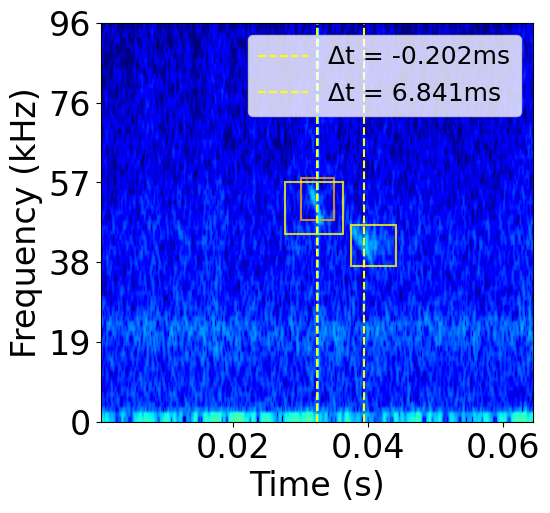

In [21]:
plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 24})
for i, sel_ind in enumerate((bd2_dets_with_overlap_human_dets.index).values):
    plt.subplot(2,4,i+1)
    selection_row = hf_bd2_file_all_dets.iloc[sel_ind]
    input_file = Path(selection_row['input_file'])
    file_name = input_file.name
    file_path = Path(RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.06
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='cyan')

    plot_humandets = hf_bd2_human_df_file[(hf_bd2_human_df_file['start_time']>=start)&(hf_bd2_human_df_file['end_time']<=(start+duration))]
    for i, row in plot_humandets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='yellow', 
                label=f"Δt = {round(1000*(row['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM']), 3)}ms")

    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.legend(fontsize=18)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

Above the human annotations within the `TP_CLASSIFICATION_THRESHOLD` are counted as overlapping with bd2 detections. This does NOT influence the bd2 true positives set because these are seen as only "human" true positives whereas we look at true values going rightward for bd2 true positives.

In [22]:
num_trues_each_col = hf_association_matrix.sum(axis=0)
human_dets_with_overlap_bd2_dets = hf_bd2_human_df_file.iloc[np.where(num_trues_each_col>1)[0]]
print(human_dets_with_overlap_bd2_dets.index.values)
hf_bd2_file_all_dets[hf_association_matrix[:,787]]

[]


,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
8213,HF,654.5232,52500.0,51840.0,13.040312,654.5205,654.5253,49531,62269,Pipistrellus pipistrellus,0.495,0.568,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


In [23]:
plt.figure(figsize=(20, 10))
plt.rcParams.update({'font.size': 24})
for i, sel_ind in enumerate((human_dets_with_overlap_bd2_dets.index).values):
    plt.subplot(2,4,i+1)
    selection_row = hf_bd2_human_df_file.iloc[sel_ind]
    file_name = f'{wav_filename}.WAV'
    file_path = Path(RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.06
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time']-start, linestyle='dashed', color='yellow')

    plot_bd2dets = hf_bd2_file_all_dets[(hf_bd2_file_all_dets['start_time']>=start)&(hf_bd2_file_all_dets['end_time']<=(start+duration))]
    for i, row in plot_bd2dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='cyan', 
                label=f"Δt = {round(1000*(row['peak_frequency_time_SPECTROGRAM'] - selection_row['peak_frequency_time']), 3)}ms")

    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.legend(fontsize=18)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

<Figure size 2000x1000 with 0 Axes>

Above the detections within the `TP_CLASSIFICATION_THRESHOLD` are part of the true positives. They are within `TP_CLASSIFICATION_THRESHOLD` of the human annotation but NOT within `OVERLAP_TIME_THRESHOLD` of each other (which is why neither of them were dropped)

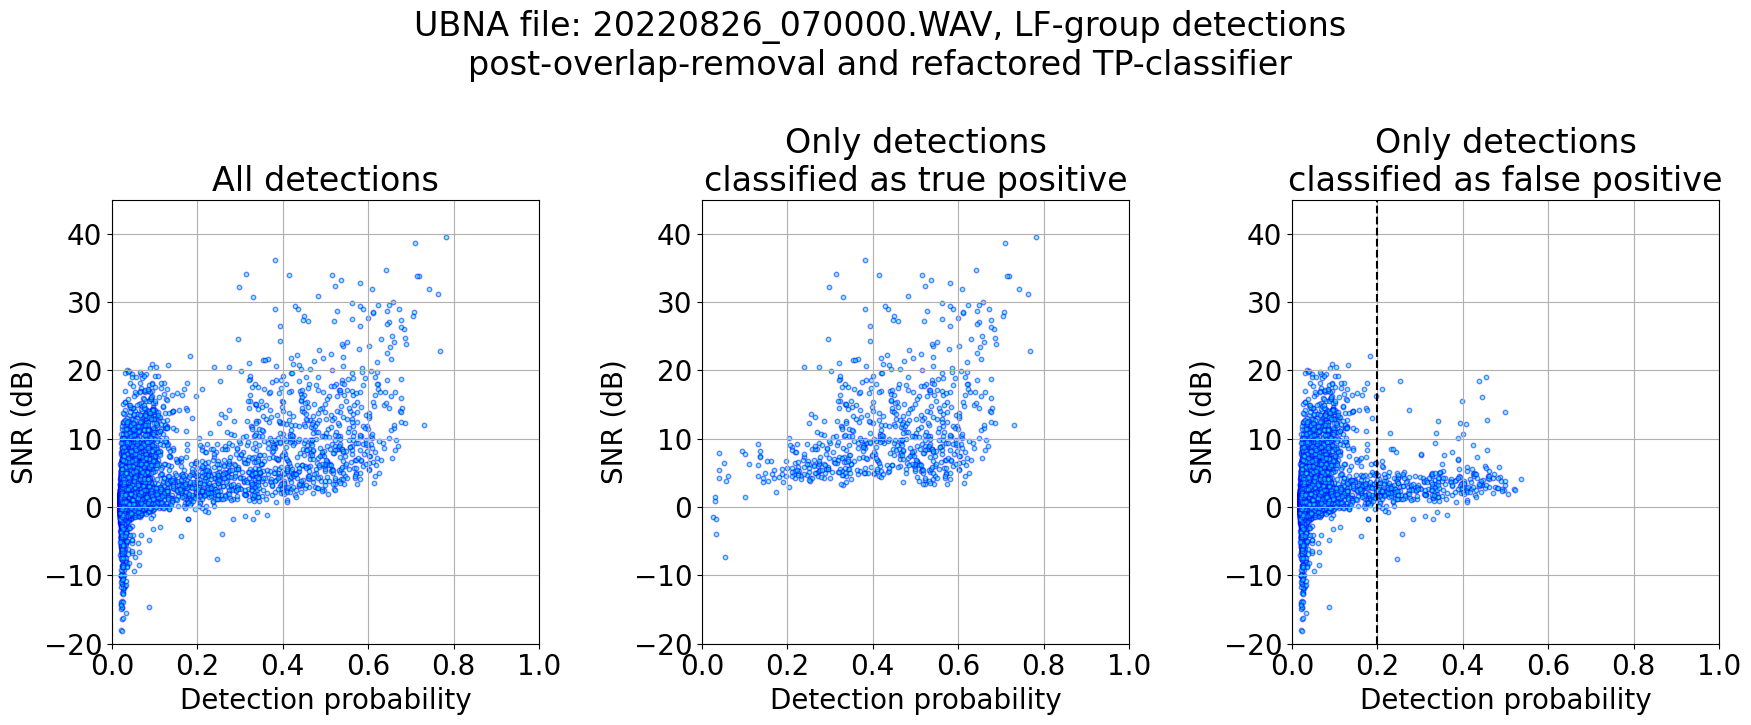

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'UBNA file: {wav_filename}.WAV, LF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(lf_bd2_file_all_dets['det_prob'].values, lf_bd2_file_all_dets['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(lf_bd2_true_positives['det_prob'].values, lf_bd2_true_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(lf_bd2_false_positives['det_prob'].values, lf_bd2_false_positives['SNR'].values,
            alpha=0.5, s=10, facecolor='cyan', edgecolor='blue')
ax.axvline(x=0.2, linestyle='dashed', color='k')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

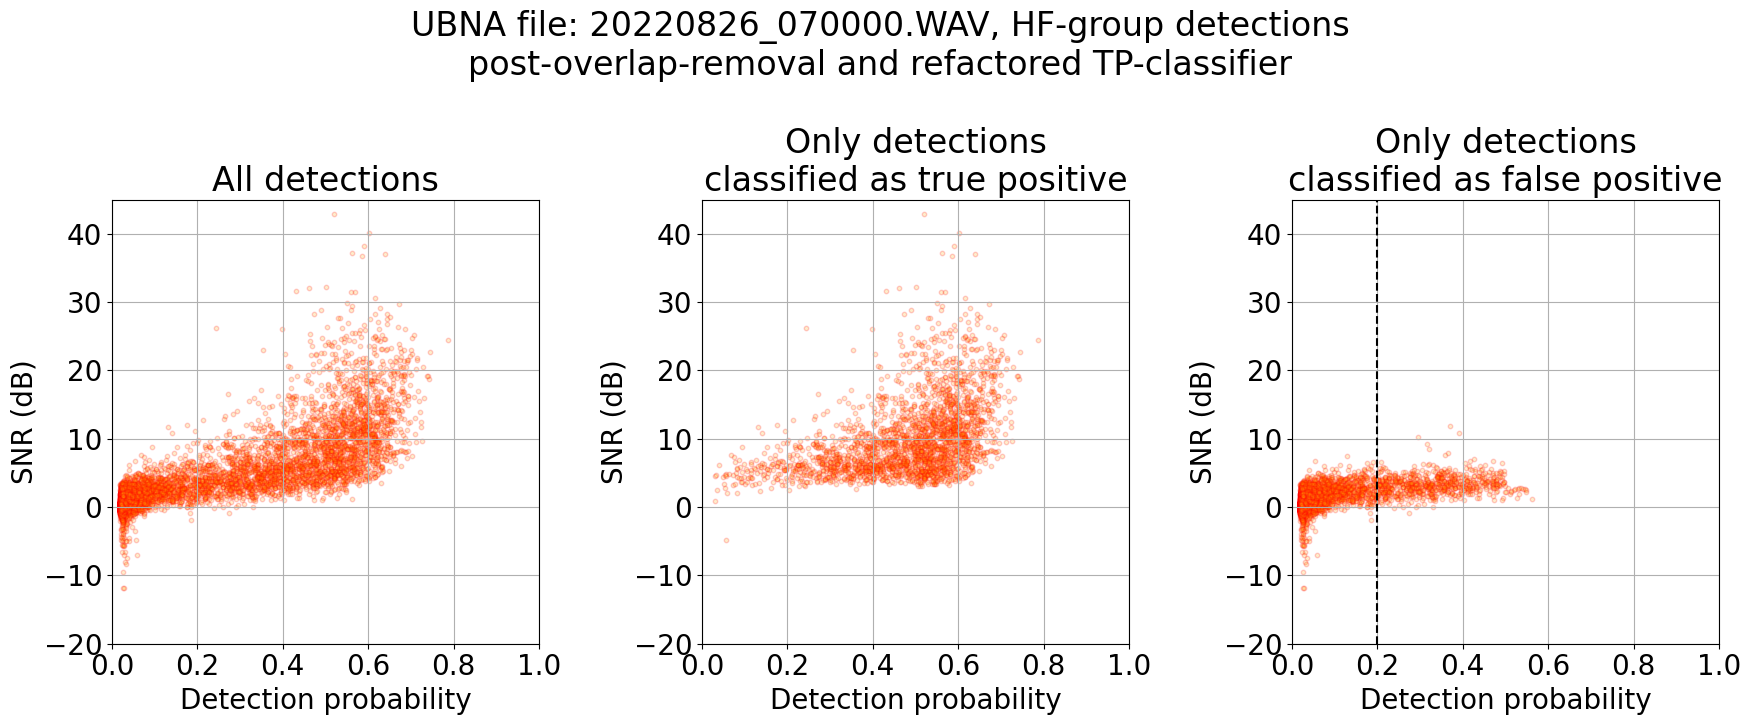

In [26]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,7.5))
plt.rcParams.update({'font.size':20})

fig.suptitle(f'UBNA file: {wav_filename}.WAV, HF-group detections\npost-overlap-removal and refactored TP-classifier')

ax = ax1
ax.set_title(f'All detections')
ax.scatter(hf_bd2_file_all_dets['det_prob'].values, hf_bd2_file_all_dets['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax2
ax.set_title(f'Only detections\nclassified as true positive')
ax.scatter(hf_bd2_true_positives['det_prob'].values, hf_bd2_true_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)

ax = ax3
ax.set_title(f'Only detections\nclassified as false positive')
ax.scatter(hf_bd2_false_positives['det_prob'].values, hf_bd2_false_positives['SNR'].values,
            alpha=0.2, s=10, facecolor='orange', edgecolor='red')
ax.axvline(x=0.2, linestyle='dashed', color='k')
ax.grid(which='both')
ax.set_xlabel('Detection probability')
ax.set_ylabel('SNR (dB)')
ax.set_xlim(0, 1.0)
ax.set_ylim(-20, 45.0)


fig.tight_layout()
plt.show()

In [27]:
suspect_lf_bd2_false_positives = lf_bd2_false_positives[lf_bd2_false_positives['det_prob']>0.2]
suspect_lf_bd2_false_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
537,LF,31.196967,24750.0,24000.0,1.052236,31.1865,31.2022,23750,29512,Nyctalus leisleri,0.138,0.322,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
550,LF,31.769033,24750.0,24960.0,1.232003,31.7585,31.7753,24609,29107,Nyctalus leisleri,0.103,0.242,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
569,LF,33.093733,25500.0,25920.0,3.818196,33.0855,33.1011,24609,28287,Nyctalus leisleri,0.215,0.370,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
575,LF,33.496567,25500.0,25920.0,4.136854,33.4915,33.5056,24609,28405,Nyctalus leisleri,0.234,0.416,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
581,LF,33.788467,24000.0,24960.0,4.613169,33.7805,33.7987,24609,28572,Nyctalus leisleri,0.118,0.226,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20846,LF,1191.425533,26250.0,25920.0,4.976283,1191.4205,1191.4393,23750,28813,Nyctalus leisleri,0.159,0.335,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
20875,LF,1192.989100,26250.0,24960.0,3.116921,1192.9835,1193.0029,24609,28014,Nyctalus leisleri,0.178,0.260,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
20879,LF,1193.254167,26250.0,24960.0,3.586618,1193.2485,1193.2620,25468,29386,Nyctalus leisleri,0.104,0.228,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
23177,LF,1339.881900,20250.0,20160.0,18.394509,1339.8795,1339.8846,16875,33444,Plecotus austriacus,0.154,0.254,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


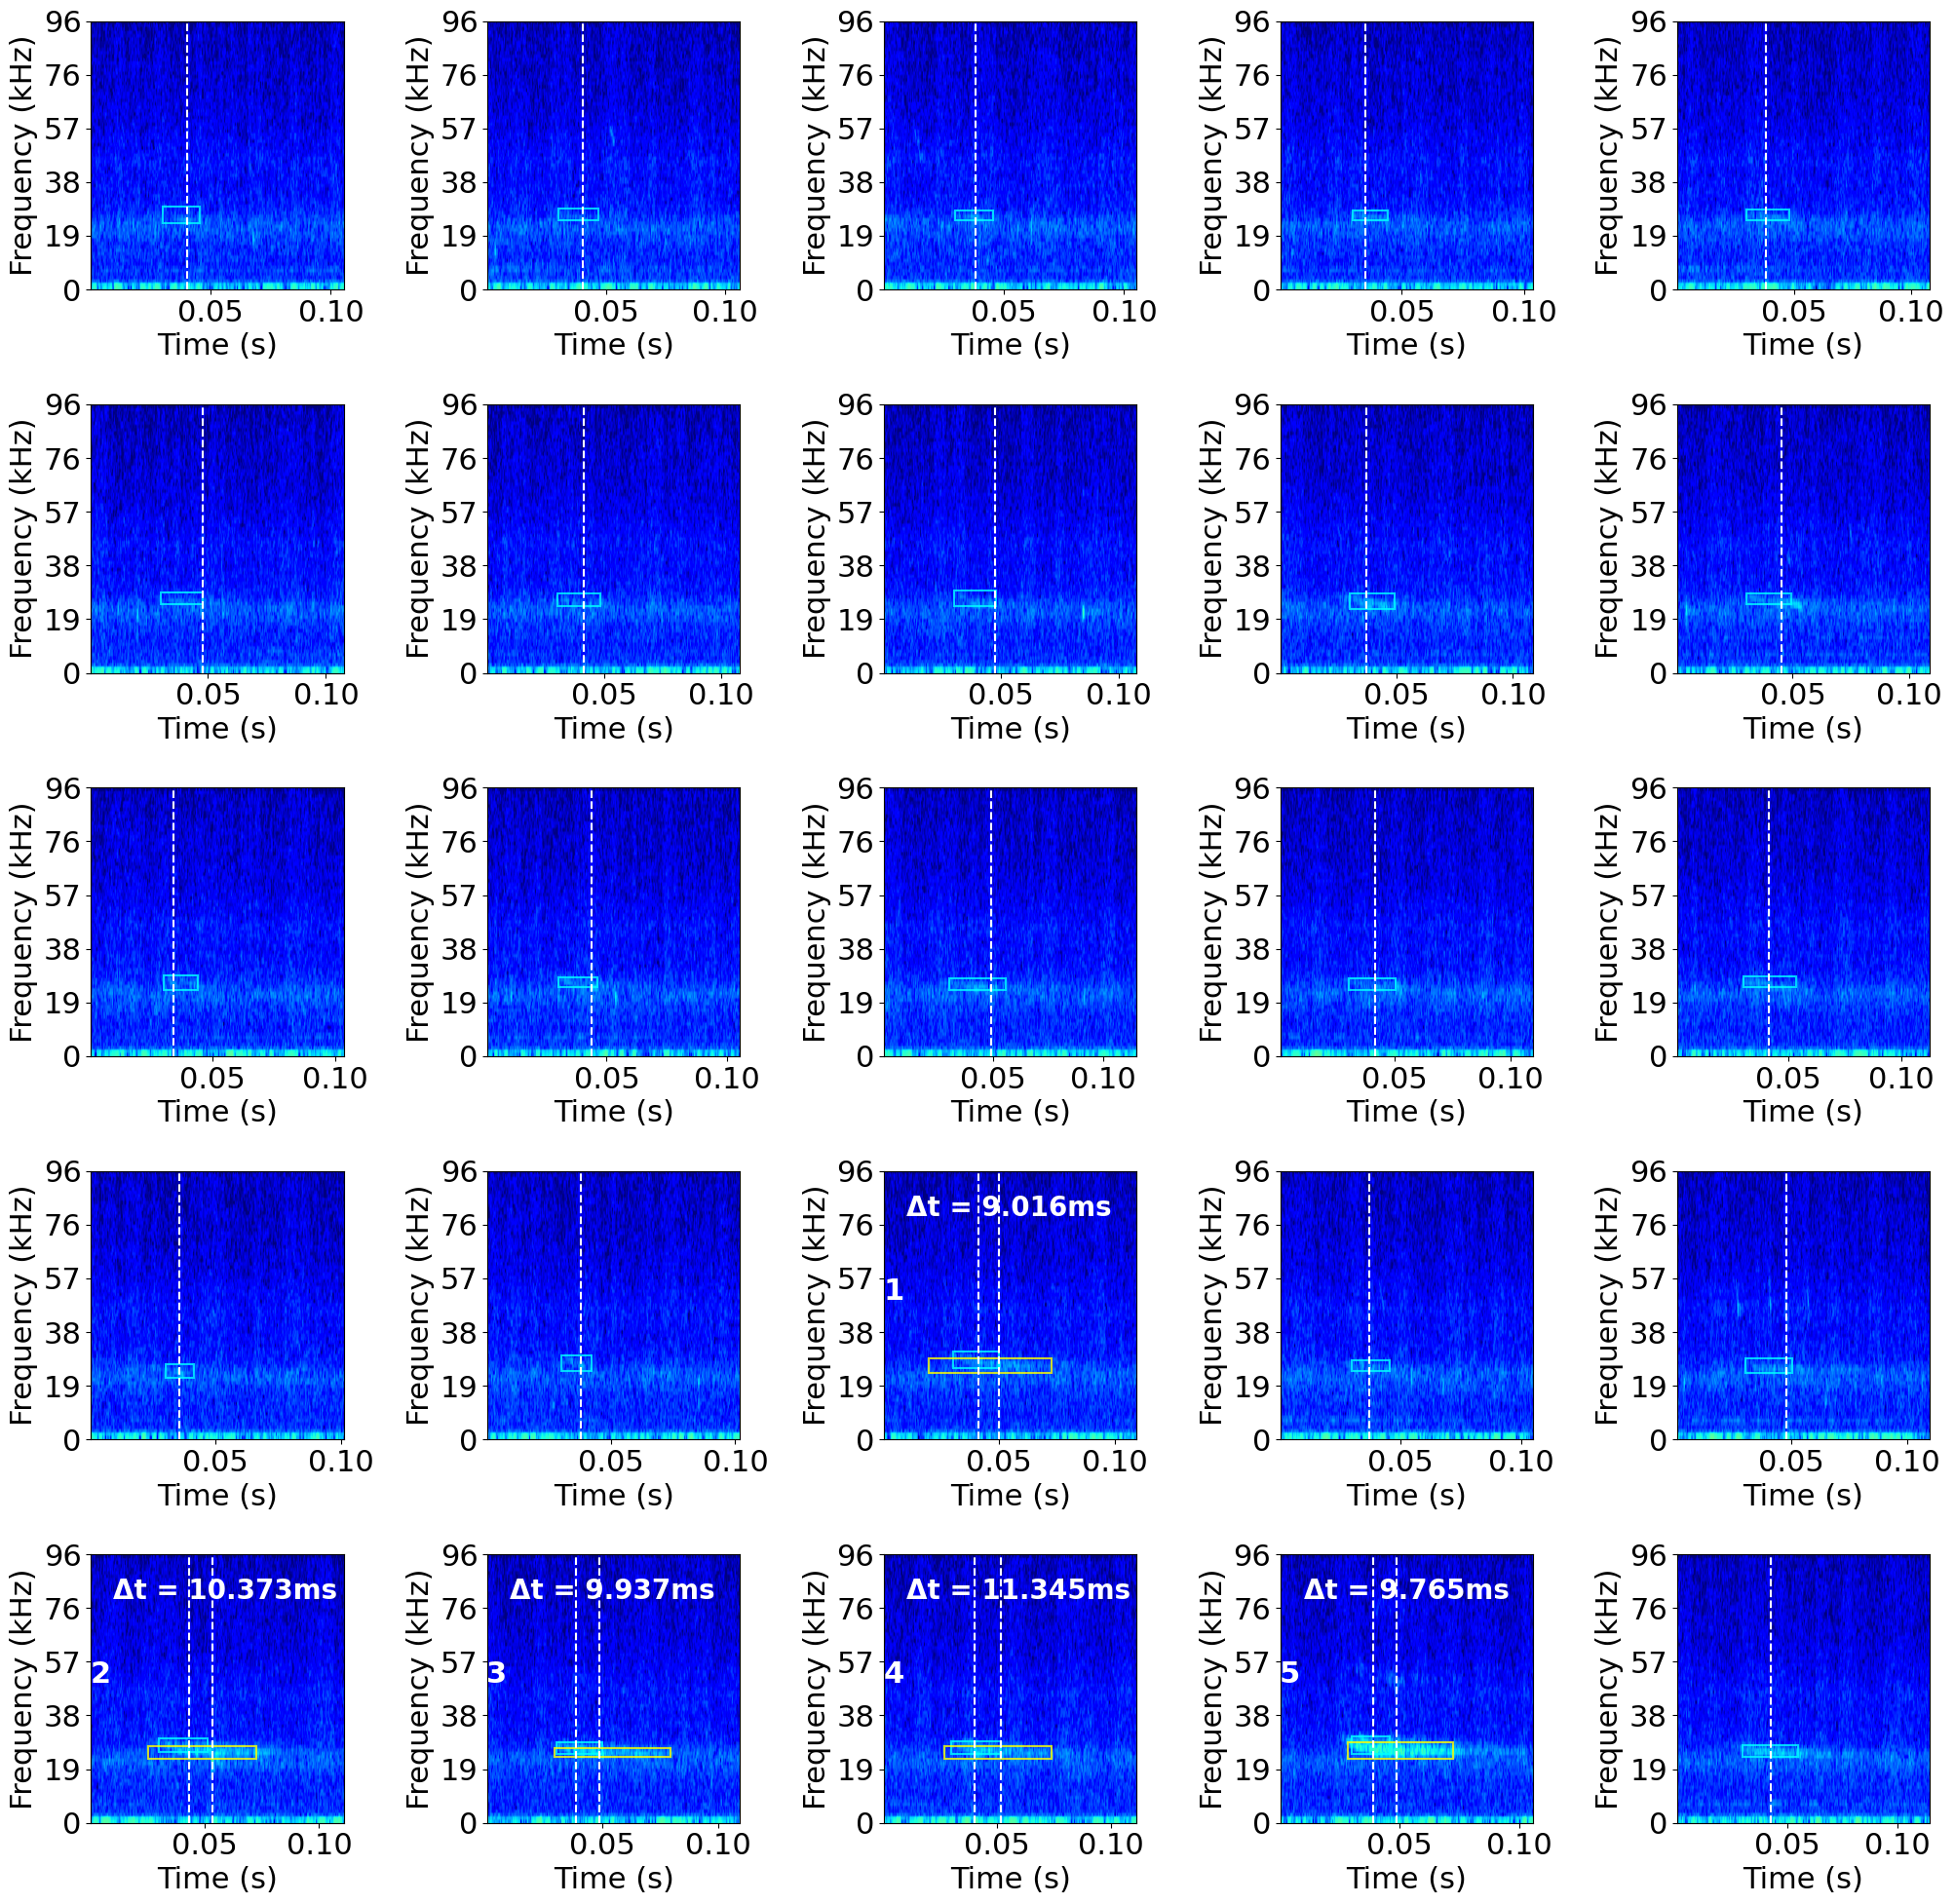

In [28]:
selections = suspect_lf_bd2_false_positives[:25].reset_index(drop=True).copy()
plt.figure(figsize=(4.1*int(np.ceil(len(selections)**0.5)), 4*int(np.ceil(len(selections)**0.5))))
plt.rcParams.update({'font.size': 22})
overlap_count = 0
for ind, selection_row in selections.iterrows():
    plt.subplot(int(np.ceil(len(selections)**0.5)), int(np.ceil(len(selections)**0.5)), ind+1)
    input_file = Path(selection_row['input_file'])
    file_name = input_file.name
    file_path = Path(RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

    plot_humandets = lf_bd2_human_df_file[(lf_bd2_human_df_file['start_time']>=start)&(lf_bd2_human_df_file['end_time']<=(start+duration))]
    for i, row in plot_humandets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if ~(np.isnan(shortest_t_delay_in_window)):
        plt.text(x=0.01, y=80e3, s=f"Δt = {round(shortest_t_distance_in_window, 3)}ms",
                fontsize=20, color='white', fontweight='bold', zorder=2)
    if (np.abs(shortest_t_distance_in_window)<32):
        overlap_count+=1
        plt.text(x=0, y=50e3, s=f'{overlap_count}', color='w', fontweight='bold')
    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [29]:
selections = suspect_lf_bd2_false_positives.reset_index(drop=True).copy()
overlap_count = 0
overlap_determination_thresh = 32
for ind, selection_row in selections.iterrows():
    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    plot_humandets = lf_bd2_human_df_file[(lf_bd2_human_df_file['start_time']>=start)&(lf_bd2_human_df_file['end_time']<=(start+duration))]
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if (np.abs(shortest_t_distance_in_window)<overlap_determination_thresh):
        overlap_count+=1
print(f'{overlap_count}/{len(selections)} ({round(overlap_count/len(selections), 3)}) HF false positives were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < {overlap_determination_thresh}ms')

35/306 (0.114) HF false positives were actually true positives with peak times distances > 8ms but < 32ms


In [30]:
suspect_hf_bd2_false_positives = hf_bd2_false_positives[hf_bd2_false_positives['det_prob']>0.2]
suspect_hf_bd2_false_positives

,freq_group,peak_frequency_time_SPECTROGRAM,peak_frequency_SPECTROGRAM,peak_frequency_WELCH,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file
15,HF,1.732900,47250.0,47040.0,3.570422,1.7295,1.7371,46953,51351,Pipistrellus pipistrellus,0.388,0.428,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
49,HF,4.166333,48000.0,48000.0,3.463646,4.1625,4.1685,45234,59329,Pipistrellus pipistrellus,0.218,0.312,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
116,HF,8.577967,41250.0,41280.0,4.962143,8.5735,8.5812,39218,47453,Pipistrellus nathusii,0.393,0.470,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
119,HF,8.681167,41250.0,40320.0,1.788974,8.6785,8.6880,38359,43377,Pipistrellus nathusii,0.203,0.227,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
120,HF,8.778500,41250.0,40320.0,2.540203,8.7755,8.7835,38359,44413,Pipistrellus nathusii,0.211,0.283,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22744,HF,1775.682900,43500.0,43200.0,2.227914,1775.6775,1775.6866,41796,46096,Pipistrellus nathusii,0.198,0.227,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
22785,HF,1778.224233,42000.0,43200.0,1.928925,1778.2205,1778.2301,39218,43998,Pipistrellus nathusii,0.220,0.273,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
22856,HF,1787.042900,43500.0,42240.0,1.932710,1787.0415,1787.0511,38359,43962,Pipistrellus nathusii,0.369,0.398,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...
22862,HF,1787.481833,45000.0,44160.0,1.970963,1787.4815,1787.4910,38359,44446,Pipistrellus nathusii,0.441,0.462,-1,Echolocation,192000,/Users/adityakrishna/Documents/Research/mila_f...


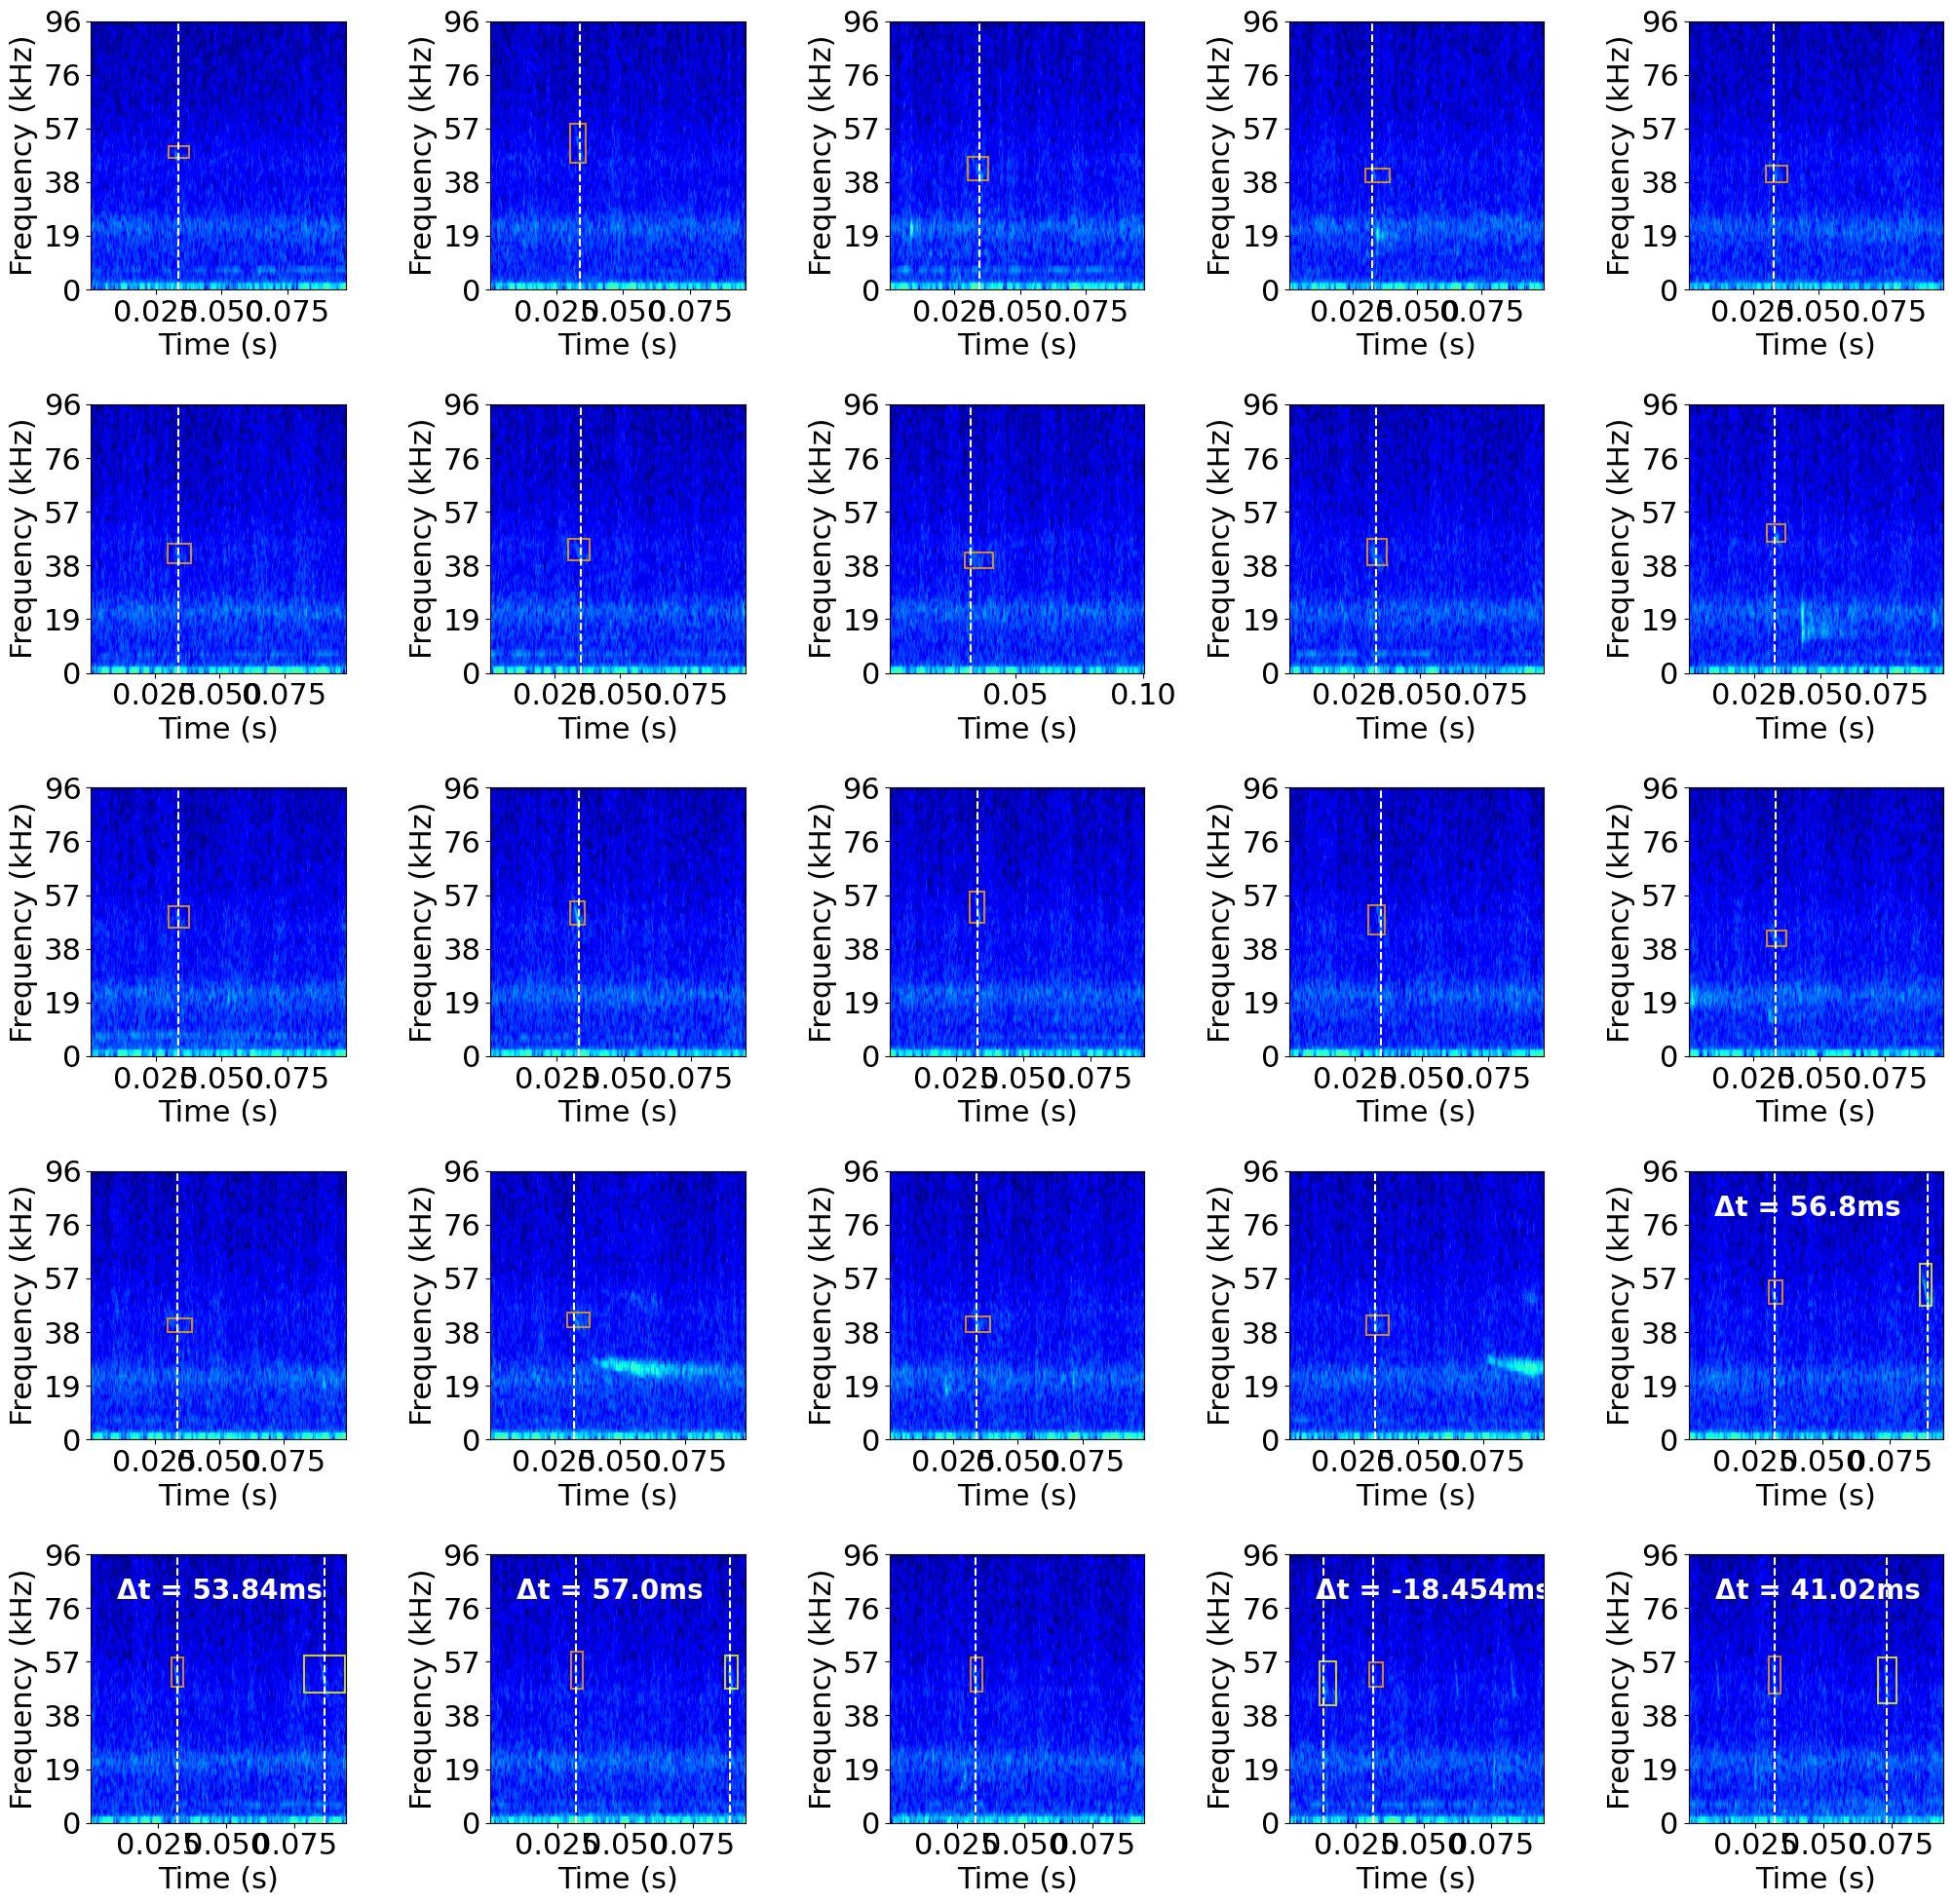

In [31]:
selections = suspect_hf_bd2_false_positives[:25].reset_index(drop=True).copy()
plt.figure(figsize=(4.1*int(np.ceil(len(selections)**0.5)), 4*int(np.ceil(len(selections)**0.5))))
plt.rcParams.update({'font.size': 22})
overlap_count = 0
for ind, selection_row in selections.iterrows():
    plt.subplot(int(np.ceil(len(selections)**0.5)), int(np.ceil(len(selections)**0.5)), ind+1)
    input_file = Path(selection_row['input_file'])
    file_name = input_file.name
    file_path = Path(RAVENTXT_HUMAN_ANNOTATIONS_SAVE_DIR) / file_name
    audio_file = sf.SoundFile(file_path)
    fs = audio_file.samplerate

    file_selections = selections[selections['input_file']==str(input_file)]
    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    audio_file.seek(int(fs*(start)))
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    audio_seg = audio_file.read(int(fs*duration))

    plt.specgram(audio_seg, NFFT=156, Fs=fs, cmap='jet', vmin=-120, vmax=0)

    ax = plt.gca()
    rect = patches.Rectangle(((selection_row['start_time'] - start), selection_row['low_freq']), 
                    (selection_row['end_time'] - selection_row['start_time']), (selection_row['high_freq'] - selection_row['low_freq']), 
                    linewidth=1.5, edgecolor=FREQ_COLORS[selection_row['freq_group']], facecolor='none', alpha=0.8)
    ax.add_patch(rect)
    ax.axvline(x=selection_row['peak_frequency_time_SPECTROGRAM']-start, linestyle='dashed', color='w')

    plot_humandets = hf_bd2_human_df_file[(hf_bd2_human_df_file['start_time']>=start)&(hf_bd2_human_df_file['end_time']<=(start+duration))]
    for i, row in plot_humandets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start), row['low_freq']), 
                        (row['end_time'] - row['start_time']), (row['high_freq'] - row['low_freq']), 
                        linewidth=1.5, edgecolor='yellow', facecolor='none', alpha=0.8)
        ax.add_patch(rect)
        ax.axvline(x=row['peak_frequency_time']-start, linestyle='dashed', color='w')
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if ~(np.isnan(shortest_t_delay_in_window)):
        plt.text(x=0.01, y=80e3, s=f"Δt = {round(shortest_t_distance_in_window, 3)}ms",
                fontsize=20, color='white', fontweight='bold', zorder=2)
    if (np.abs(shortest_t_distance_in_window)<10):
        overlap_count+=1
        plt.text(x=0, y=50e3, s=f'{overlap_count}', color='w', fontweight='bold')
    plt.yticks(ticks=np.linspace(0, fs/2, 6), labels=np.linspace(0, fs/2000, 6).astype('int'))
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")

plt.tight_layout()
plt.show()

In [32]:
selections = suspect_hf_bd2_false_positives.reset_index(drop=True).copy()
overlap_count = 0
overlap_determination_thresh = 20
for ind, selection_row in selections.iterrows():
    raventxt_human_filename = f'{input_file.stem}_manually_verified_by_AK_with_groups'

    start = selection_row['start_time']-0.03
    duration = (selection_row['end_time']-selection_row['start_time'])+0.09
    plot_humandets = hf_bd2_human_df_file[(hf_bd2_human_df_file['start_time']>=start)&(hf_bd2_human_df_file['end_time']<=(start+duration))]
    shortest_t_delay_in_window = np.abs(1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    shortest_t_distance_in_window = (1000*(plot_humandets['peak_frequency_time'] - selection_row['peak_frequency_time_SPECTROGRAM'])).min()
    if (np.abs(shortest_t_distance_in_window)<overlap_determination_thresh):
        overlap_count+=1
print(f'{overlap_count}/{len(selections)} ({round(overlap_count/len(selections), 3)}) HF false positives were actually true positives with peak times distances > {int(1000*TP_CLASSIFICATION_THRESHOLD)}ms but < {overlap_determination_thresh}ms')

12/699 (0.017) HF false positives were actually true positives with peak times distances > 8ms but < 20ms
